<a href="https://colab.research.google.com/github/Sumitsharma12321/Deep-Learning-demo/blob/main/11_Age_Gender_revised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jangedoo/utkface-new")

print("Path to dataset files:", path)

100%|██████████| 331M/331M [00:06<00:00, 56.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jangedoo/utkface-new/versions/1


In [8]:
import os

print(os.listdir(path))

['utkface_aligned_cropped', 'crop_part1', 'UTKFace']


In [9]:
image_dir = os.path.join(path, "UTKFace")

print(os.listdir(image_dir)[:5])

['27_0_1_20170117005926266.jpg.chip.jpg', '1_0_1_20170110213113882.jpg.chip.jpg', '28_1_2_20170116165514344.jpg.chip.jpg', '29_0_3_20170119195116490.jpg.chip.jpg', '39_1_0_20170103182037472.jpg.chip.jpg']


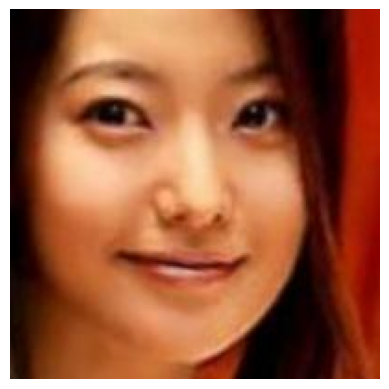

In [11]:
import cv2
import matplotlib.pyplot as plt

img_name = os.listdir(image_dir)[2]
img_path = os.path.join(image_dir, img_name)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

In [13]:
filename = os.listdir(image_dir)[2]

age = int(filename.split('_')[0])
gender = int(filename.split('_')[1])
race = int(filename.split('_')[2])

print("Age:", age)
print("Gender:", gender)
print("Race:", race)

Age: 28
Gender: 1
Race: 2


In [15]:
import os

age = []
gender = []
race = []
img_path = []

for file in os.listdir(image_dir):

    age.append(int(file.split('_')[0]))
    gender.append(int(file.split('_')[1]))
    img_path.append(file)

print("Total Images:", len(img_path))

Total Images: 23708


In [43]:
import pandas as pd

df = pd.DataFrame({'age':age,'gender':gender,'img':img_path})

In [44]:
df

,age,gender,img
0,27,0,27_0_1_20170117005926266.jpg.chip.jpg
1,1,0,1_0_1_20170110213113882.jpg.chip.jpg
2,28,1,28_1_2_20170116165514344.jpg.chip.jpg
3,29,0,29_0_3_20170119195116490.jpg.chip.jpg
4,39,1,39_1_0_20170103182037472.jpg.chip.jpg
...,...,...,...
23703,24,1,24_1_1_20170112234612457.jpg.chip.jpg
23704,1,0,1_0_0_20161219200338012.jpg.chip.jpg
23705,17,1,17_1_0_20170117140619087.jpg.chip.jpg
23706,5,0,5_0_2_20161219151837283.jpg.chip.jpg


In [46]:
shuffled = df.sample(frac=1, random_state=0).reset_index(drop=True)
train_df = shuffled.iloc[:20000].copy()
test_df  = shuffled.iloc[20000:].copy()
print("Train:", train_df.shape, " Test:", test_df.shape)

Train: (20000, 3)  Test: (3708, 3)


In [47]:
# Data Augumentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=30,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)
BATCH =32
IMG_SIZE = (200,200)

In [50]:
train_generator = train_datagen.flow_from_dataframe(train_df,
                                                    directory= image_dir,
                                                    x_col = 'img',
                                                    y_col = ['age','gender'],
                                                    target_size = IMG_SIZE,
                                                    batch_size=BATCH,
                                                    class_mode= 'multi_output'
                                                    )

test_generator = test_datagen.flow_from_dataframe(test_df,
                                                  directory = image_dir,
                                                  x_col = 'img',
                                                  y_col=['age','gender'],
                                                  target_size = IMG_SIZE,
                                                  batch_size=BATCH,
                                                  class_mode= 'multi_output')

Found 20000 validated image filenames.
Found 3708 validated image filenames.


In [51]:
from keras.applications.vgg16 import VGG16
from keras.layers import *
from keras.models  import Model

In [52]:
vggnet = VGG16(include_top =False, input_shape=(200,200,3))

In [53]:
vggnet.trainable=False

output = vggnet.layers[-1].output

flatten = Flatten()(output)

dense1 = Dense(512, activation='relu')(flatten)
dense2 = Dense(512, activation='relu')(flatten)

dense3 = Dense(512,activation='relu')(dense1)
dense4 = Dense(512,activation='relu')(dense2)

output1 = Dense(1, activation='linear',name='age')(dense3)
output2 = Dense(1,activation='sigmoid',name ='gender')(dense4)

In [54]:
model = Model(inputs=vggnet.input,outputs=[output1,output2])

In [55]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 200, 200,  │      1,792 │ input_layer_1[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 200, 200,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 100, 100,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 100, 100,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 100, 100,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 50, 50,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 50, 50,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 50, 50,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 50, 50,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 25, 25,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 25, 25,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 25, 25,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 25, 25,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 12, 12,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 12, 12,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 12, 12,    │  2,359,808 │ block5_conv1[0][

 Total params: 34,116,418 (130.14 MB)

 Trainable params: 19,401,730 (74.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

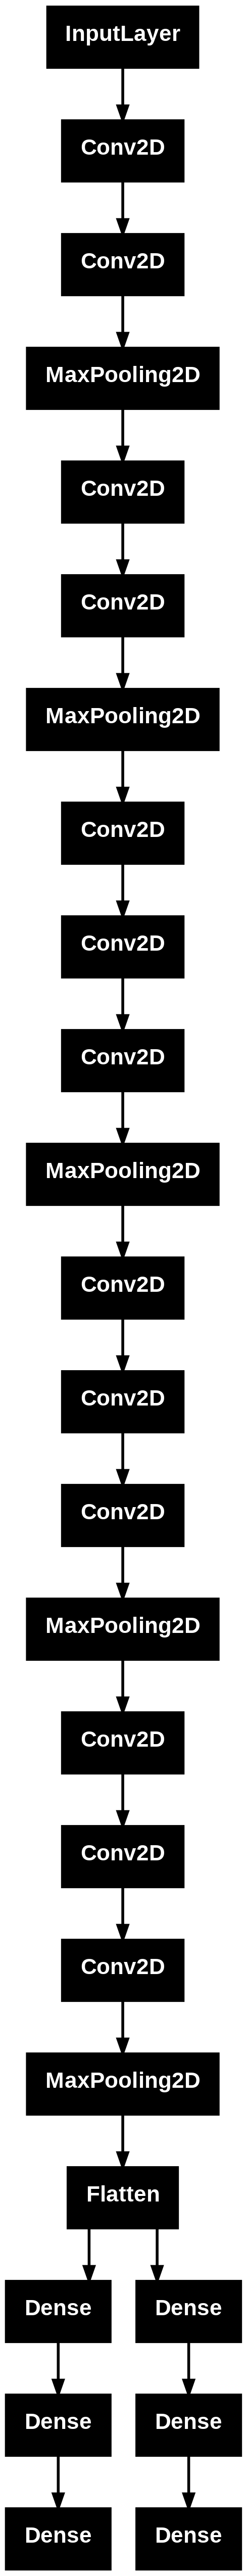

In [56]:
from keras.utils import plot_model
plot_model(model)

In [57]:
model.compile(optimizer='adam',
              loss={'age':'mae','gender':'binary_crossentropy'},
              metrics={'age':'mae','gender':'accuracy'},
              loss_weights={'age':1,'gender':99})

In [58]:
def wrap_generator(gen):
    """Convert list-of-outputs to dict-of-outputs for named Keras heads."""
    for x, y in gen:
        # y[0] = age (float), y[1] = gender string → already float from datagen
        yield x, {'age': y[0], 'gender': y[1]}

In [59]:
steps_per_epoch  = len(train_generator)
validation_steps = len(test_generator)

In [60]:
history = model.fit(
    wrap_generator(train_generator),
    steps_per_epoch=steps_per_epoch,
    epochs=10,
    validation_data=wrap_generator(test_generator),
    validation_steps=validation_steps,
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 268s 423ms/step - age_loss: 10.9537 - age_mae: 10.9537 - gender_accuracy: 0.7361 - gender_loss: 0.5350 - loss: 63.9173 - val_age_loss: 9.2227 - val_age_mae: 9.2262 - val_gender_accuracy: 0.8296 - val_gender_loss: 0.3715 - val_loss: 45.9980
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 250s 400ms/step - age_loss: 9.3934 - age_mae: 9.3934 - gender_accuracy: 0.7838 - gender_loss: 0.4478 - loss: 53.7279 - val_age_loss: 8.3211 - val_age_mae: 8.3211 - val_gender_accuracy: 0.8545 - val_gender_loss: 0.3350 - val_loss: 41.4908
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 247s 396ms/step - age_loss: 8.9625 - age_mae: 8.9625 - gender_accuracy: 0.8043 - gender_loss: 0.4149 - loss: 50.0400 - val_age_loss: 8.2625 - val_age_mae: 8.2625 - val_gender_accuracy: 0.8548 - val_gender_loss: 0.3134 - val_loss: 39.2864
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 251s 402ms/step - age_loss: 8.7712 - age_mae: 8.7712 - gender_accuracy: 0.8120 - gender_loss: 0.4043 - loss: 48.7927 - val_a

In [71]:
# Check val accuracy after training
print("Best Val Gender Accuracy:", max(history.history['val_gender_accuracy']))
print("Best Val Age MAE        :", min(history.history['val_age_mae']))

Best Val Gender Accuracy: 0.8659654855728149
Best Val Age MAE        : 7.272273063659668


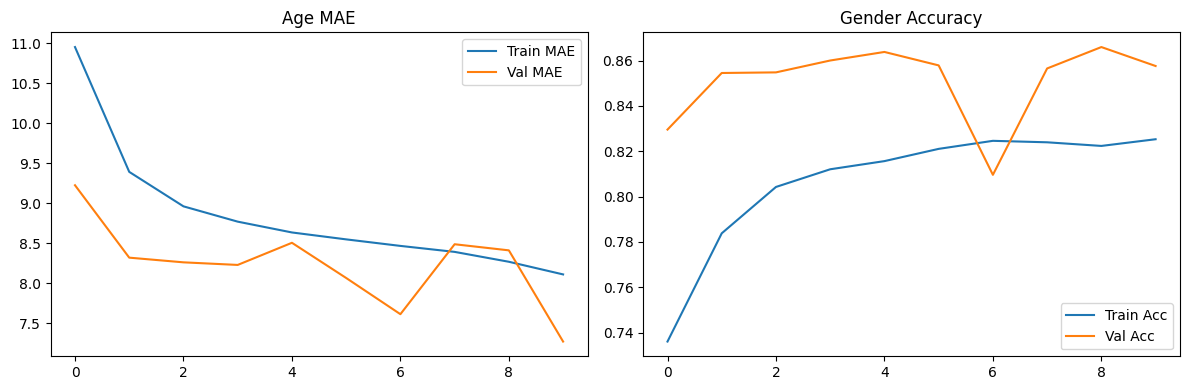

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['age_mae'],       label='Train MAE')
axes[0].plot(history.history['val_age_mae'],   label='Val MAE')
axes[0].set_title('Age MAE')
axes[0].legend()

axes[1].plot(history.history['gender_accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_gender_accuracy'], label='Val Acc')
axes[1].set_title('Gender Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()


In [63]:
import cv2

In [64]:
test_img = cv2.imread('/content/Sumit photo 3.jpeg')

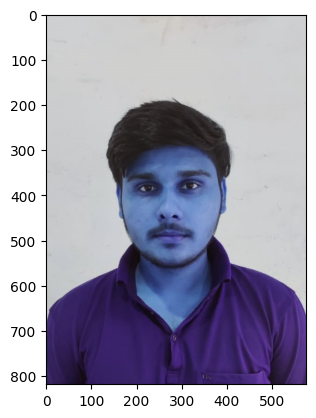

In [65]:
plt.imshow(test_img)

In [66]:
test_img.shape

(819, 576, 3)

In [75]:
import numpy as np
img = cv2.imread("/content/Sumit photo 3.jpeg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (200, 200))

# ── Debug check ──
print("Image shape   :", img.shape)        # must be (200, 200, 3)
print("Pixel min/max :", img.min(), img.max())  # must be 0 - 255

img = img / 255.0
img = np.expand_dims(img, axis=0)

print("Final shape   :", img.shape)        # must be (1, 200, 200, 3)
print("After scaling :", img.min(), img.max())  # must be 0.0 - 1.0

# ── Predict ──
age_pred, gender_pred = model.predict(img, verbose=0)
age    = int(np.clip(age_pred[0][0], 0, 100))
gender = 'Female' if gender_pred[0][0] > 0.5 else 'Male'
confidence = gender_pred[0][0] if gender == 'Female' else 1 - gender_pred[0][0]

print(f"\nPredicted Age    : {age} years")
print(f"Predicted Gender : {gender} ({confidence*100:.1f}% confidence)")

Image shape   : (200, 200, 3)
Pixel min/max : 5 233
Final shape   : (1, 200, 200, 3)
After scaling : 0.0196078431372549 0.9137254901960784

Predicted Age    : 36 years
Predicted Gender : Male (89.6% confidence)
